# AMRIE — Feature Correlation Analysis

This notebook investigates the linear relationships among the engineered
market-state features used by the Adaptive Market Regime Intelligence Engine.

The objective is to identify potentially redundant feature dimensions
before time-aware splitting, scaling, and market-regime detection.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
feature_columns = [
    "return",
    "log_return",
    "volatility_20d",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_histogram",
    "atr_14",
    "volume_change",
    "volume_ma_20",
]

features = pd.read_csv("../data/features/nifty50_features.csv")

features.head()

,Date,Open,High,Low,Close,Volume,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
0,2022-02-01,17529.449219,17622.400391,17244.550781,17576.849609,386400,0.013668,0.013575,0.010512,60.680331,-117.236885,-45.520134,-71.716751,290.674486,0.201119,281070.0
1,2022-02-02,17706.199219,17794.599609,17674.800781,17780.000000,271200,0.011558,0.011492,0.010586,64.074128,-88.394175,-54.094942,-34.299233,285.465594,-0.298137,282260.0
2,2022-02-03,17767.750000,17781.150391,17511.150391,17560.199219,226600,-0.012362,-0.012439,0.010804,58.218993,-82.323235,-59.740601,-22.582634,284.360909,-0.164454,281015.0
3,2022-02-04,17590.199219,17617.800781,17462.550781,17516.300781,261400,-0.002500,-0.002503,0.010602,57.096792,-80.130513,-63.818583,-16.311930,275.138701,0.153575,282260.0
4,2022-02-07,17456.300781,17536.750000,17119.400391,17213.599609,265000,-0.017281,-0.017432,0.011181,49.947410,-101.646503,-71.384167,-30.262336,285.296623,0.013772,283545.0


In [2]:
feature_data = features[feature_columns]

feature_data.head()

,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
0,0.013668,0.013575,0.010512,60.680331,-117.236885,-45.520134,-71.716751,290.674486,0.201119,281070.0
1,0.011558,0.011492,0.010586,64.074128,-88.394175,-54.094942,-34.299233,285.465594,-0.298137,282260.0
2,-0.012362,-0.012439,0.010804,58.218993,-82.323235,-59.740601,-22.582634,284.360909,-0.164454,281015.0
3,-0.002500,-0.002503,0.010602,57.096792,-80.130513,-63.818583,-16.311930,275.138701,0.153575,282260.0
4,-0.017281,-0.017432,0.011181,49.947410,-101.646503,-71.384167,-30.262336,285.296623,0.013772,283545.0


In [3]:
feature_data

,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
0,0.013668,0.013575,0.010512,60.680331,-117.236885,-45.520134,-71.716751,290.674486,0.201119,281070.0
1,0.011558,0.011492,0.010586,64.074128,-88.394175,-54.094942,-34.299233,285.465594,-0.298137,282260.0
2,-0.012362,-0.012439,0.010804,58.218993,-82.323235,-59.740601,-22.582634,284.360909,-0.164454,281015.0
3,-0.002500,-0.002503,0.010602,57.096792,-80.130513,-63.818583,-16.311930,275.138701,0.153575,282260.0
4,-0.017281,-0.017432,0.011181,49.947410,-101.646503,-71.384167,-30.262336,285.296623,0.013772,283545.0
...,...,...,...,...,...,...,...,...,...,...
1105,0.009614,0.009568,0.007643,49.545372,16.474980,62.408656,-45.933676,236.148875,-0.043426,348460.0
1106,-0.000442,-0.000442,0.007601,49.257995,11.540076,52.234940,-40.694864,225.463297,0.370695,347900.0
1107,0.011042,0.010982,0.007881,56.108514,28.669792,47.521910,-18.852118,230.658859,-0.031064,351505.0
1108,0.002761,0.002757,0.007751,57.664494,47.104622,47.438453,-0.333830,225.315341,-0.055634,352890.0


In [4]:
correlation_matrix = feature_data.corr(method="pearson")

correlation_matrix

,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
return,1.000000,0.999942,0.030024,0.330969,0.046807,-0.011418,0.180579,0.005774,-0.091708,0.012465
log_return,0.999942,1.000000,0.026594,0.332217,0.048556,-0.009876,0.181546,0.002451,-0.092534,0.011094
volatility_20d,0.030024,0.026594,1.000000,-0.188364,-0.274008,-0.337518,0.130352,0.792945,-0.036460,0.514751
rsi_14,0.330969,0.332217,-0.188364,1.000000,0.813163,0.656949,0.625403,-0.335061,-0.008116,-0.101178
macd,0.046807,0.048556,-0.274008,0.813163,1.000000,0.948081,0.357418,-0.403827,0.012763,-0.123824
macd_signal,-0.011418,-0.009876,-0.337518,0.656949,0.948081,1.000000,0.041839,-0.435397,0.010186,-0.170469
macd_histogram,0.180579,0.181546,0.130352,0.625403,0.357418,0.041839,1.000000,0.009945,0.010185,0.111603
atr_14,0.005774,0.002451,0.792945,-0.335061,-0.403827,-0.435397,0.009945,1.000000,-0.017822,0.760641
volume_change,-0.091708,-0.092534,-0.036460,-0.008116,0.012763,0.010186,0.010185,-0.017822,1.000000,-0.028468
volume_ma_20,0.012465,0.011094,0.514751,-0.101178,-0.123824,-0.170469,0.111603,0.760641,-0.028468,1.000000


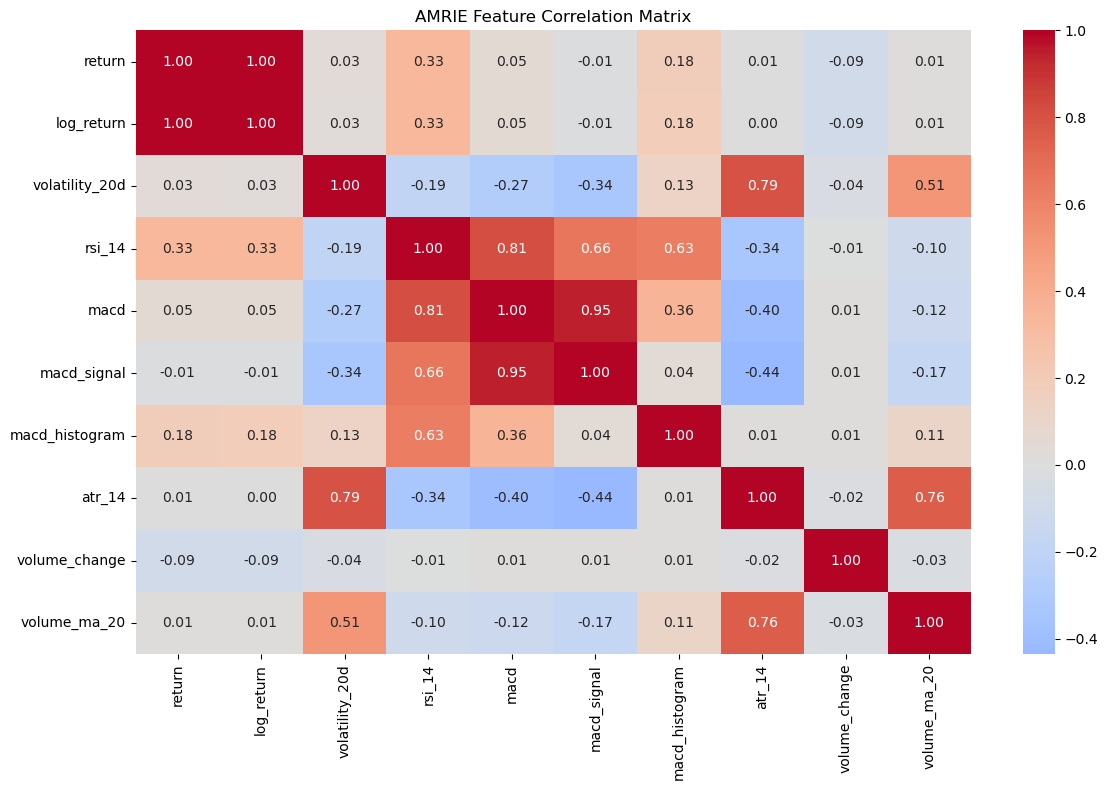

In [5]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("AMRIE Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [6]:
correlation_threshold = 0.80

high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= correlation_threshold:
            high_correlation_pairs.append(
                {
                    "feature_1": correlation_matrix.index[i],
                    "feature_2": correlation_matrix.columns[j],
                    "correlation": correlation,
                }
            )

high_correlation_pairs

[{'feature_1': 'return',
  'feature_2': 'log_return',
  'correlation': 0.9999423778928827},
 {'feature_1': 'rsi_14',
  'feature_2': 'macd',
  'correlation': 0.8131626910774361},
 {'feature_1': 'macd',
  'feature_2': 'macd_signal',
  'correlation': 0.9480808034326779}]

In [7]:
high_correlation_df = pd.DataFrame(high_correlation_pairs)

high_correlation_df

,feature_1,feature_2,correlation
0,return,log_return,0.999942
1,rsi_14,macd,0.813163
2,macd,macd_signal,0.948081


In [8]:
print("Feature matrix shape:", feature_data.shape)
print("Number of features:", feature_data.shape[1])
print("Features:")
print(feature_data.columns.tolist())

Feature matrix shape: (1110, 10)
Number of features: 10
Features:
['return', 'log_return', 'volatility_20d', 'rsi_14', 'macd', 'macd_signal', 'macd_histogram', 'atr_14', 'volume_change', 'volume_ma_20']
